# **Titanic Chido**

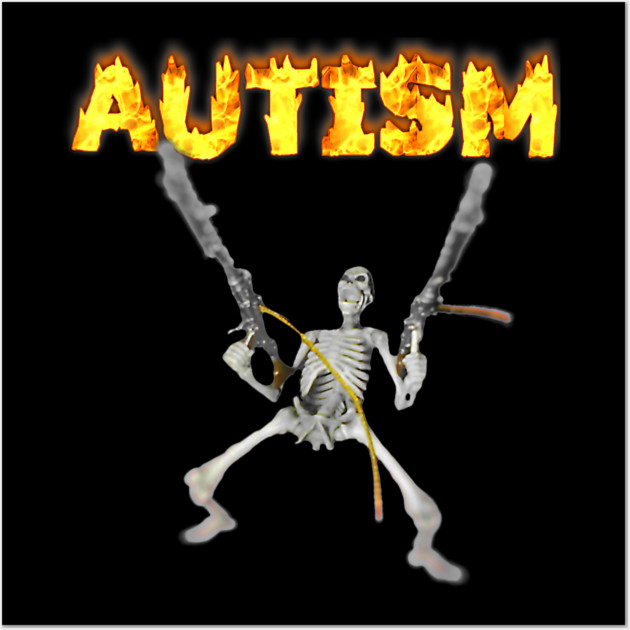

# 1. Carga de datos chida del dataset 💯

In [1]:
import pandas as pd

datos = pd.read_csv('train.csv')

In [2]:
datos.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [3]:
datos.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


# 2.Exploracion de los datos chida del Titanic ✈

<Axes: xlabel='Survived', ylabel='count'>

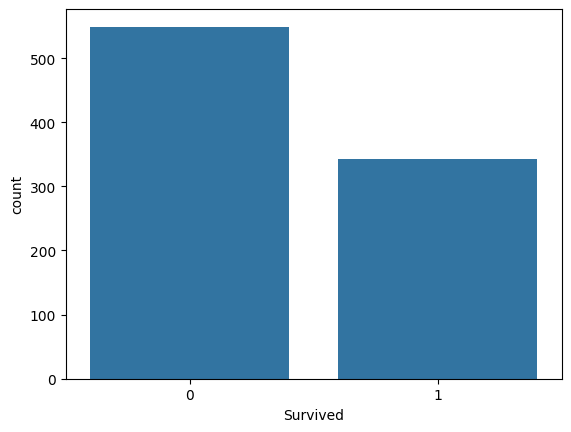

In [4]:
import seaborn as sb

sb.countplot(x="Survived", data=datos)

<Axes: xlabel='Survived', ylabel='count'>

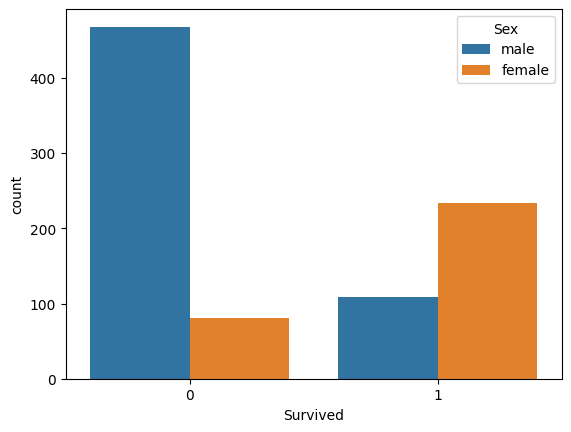

In [5]:
sb.countplot(x="Survived", data=datos, hue="Sex")

# 3.Limpieza chida y Preprocesamiento chido de los datos 🐢

In [6]:
datos.isna().sum()

,0
PassengerId,0
Survived,0
Pclass,0
Name,0
Sex,0
Age,177
SibSp,0
Parch,0
Ticket,0
Fare,0


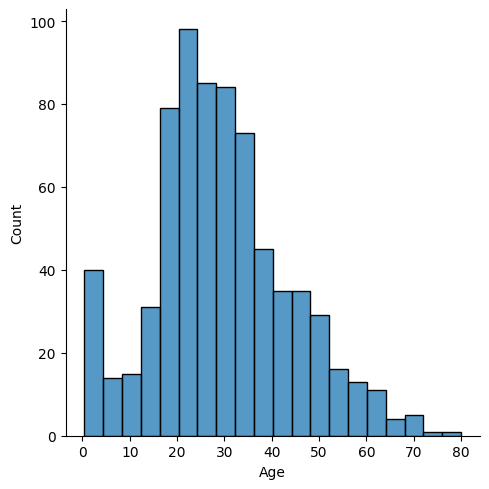

In [7]:
sb.displot(x="Age", data=datos)

In [8]:
datos["Age"]

,Age
0,22.0
1,38.0
2,26.0
3,35.0
4,35.0
...,...
886,27.0
887,19.0
888,NaN
889,26.0


In [9]:
datos["Age"].mean()

np.float64(29.69911764705882)

In [10]:
datos["Age"].fillna(datos["Age"].mean())

,Age
0,22.000000
1,38.000000
2,26.000000
3,35.000000
4,35.000000
...,...
886,27.000000
887,19.000000
888,29.699118
889,26.000000


In [11]:
datos["Age"] = datos["Age"].fillna(datos["Age"].mean())

In [12]:
datos["Age"]


,Age
0,22.000000
1,38.000000
2,26.000000
3,35.000000
4,35.000000
...,...
886,27.000000
887,19.000000
888,29.699118
889,26.000000


In [13]:
datos.isna().sum()

,0
PassengerId,0
Survived,0
Pclass,0
Name,0
Sex,0
Age,0
SibSp,0
Parch,0
Ticket,0
Fare,0


In [14]:
datos = datos.drop(["Cabin"], axis=1)

In [15]:
datos["Embarked"].value_counts()

,count
Embarked,
S,644
C,168
Q,77


In [16]:
datos = datos.dropna()

In [17]:
datos.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,S


In [18]:
datos = datos.drop(["Name", "PassengerId", "Ticket"], axis=1)

# 4.Preparacion del modelo chida ☕

In [19]:
dummies_sex = pd.get_dummies(datos["Sex"], drop_first=True)

In [20]:
datos = datos.join(dummies_sex)
datos = datos.drop(["Sex"], axis=1)

<Axes: xlabel='Survived', ylabel='count'>

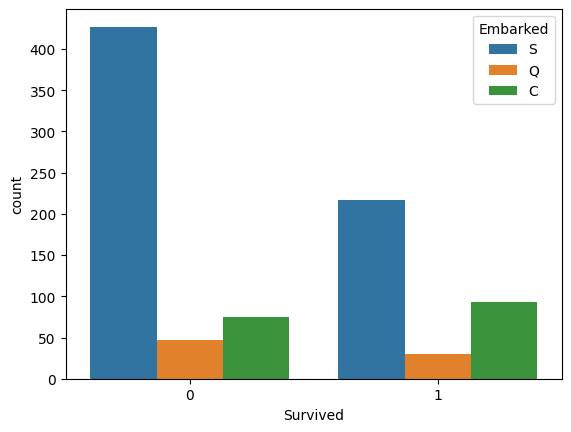

In [21]:
sb.countplot(x="Survived", data=datos, hue="Embarked")

In [22]:
dummies_embarked = pd.get_dummies(datos["Embarked"], drop_first=True)

In [23]:
datos = datos.join(dummies_embarked)
datos = datos.drop(["Embarked"], axis=1)

<Axes: >

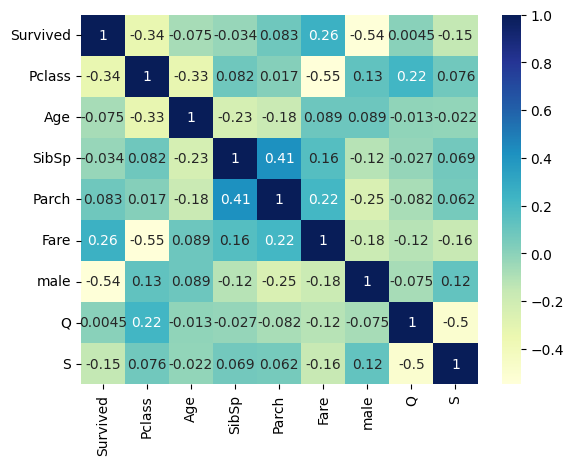

In [24]:
sb.heatmap(datos.corr(), annot=True, cmap="YlGnBu")

<Axes: xlabel='Survived', ylabel='count'>

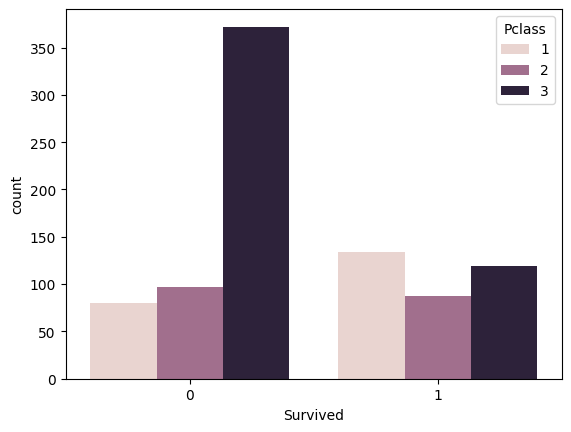

In [25]:
sb.countplot(x="Survived", data=datos, hue="Pclass")

In [26]:
x = datos.drop(["Survived"], axis=1)
y = datos["Survived"]

In [27]:
from sklearn.model_selection import train_test_split

x_ent, x_pru, y_ent, y_pru = train_test_split(x, y, test_size=.2)

# 5.Arbol de Decisión 🪓

In [30]:
from sklearn.tree import DecisionTreeClassifier

modelo = DecisionTreeClassifier(max_depth=10)
modelo.fit(x_ent, y_ent)
predicciones = modelo.predict(x_pru)

In [31]:
from sklearn.metrics import accuracy_score
accuracy_score(y_pru, predicciones)

0.7921348314606742

In [35]:
from sklearn.tree import DecisionTreeClassifier

resultados = []
for i in range(1, 15):
  modelo = DecisionTreeClassifier(max_depth=i)
  modelo.fit(x_ent, y_ent)
  predicciones = modelo.predict(x_pru)
  exactitud = accuracy_score(y_pru, predicciones)
  print(f"Resultado para {i}: {exactitud}")
  resultados.append(exactitud)

Resultado para 1: 0.8370786516853933
Resultado para 2: 0.7528089887640449
Resultado para 3: 0.7921348314606742
Resultado para 4: 0.8033707865168539
Resultado para 5: 0.8089887640449438
Resultado para 6: 0.8426966292134831
Resultado para 7: 0.8146067415730337
Resultado para 8: 0.7921348314606742
Resultado para 9: 0.8146067415730337
Resultado para 10: 0.797752808988764
Resultado para 11: 0.8089887640449438
Resultado para 12: 0.8089887640449438
Resultado para 13: 0.8089887640449438
Resultado para 14: 0.7921348314606742


<Axes: >

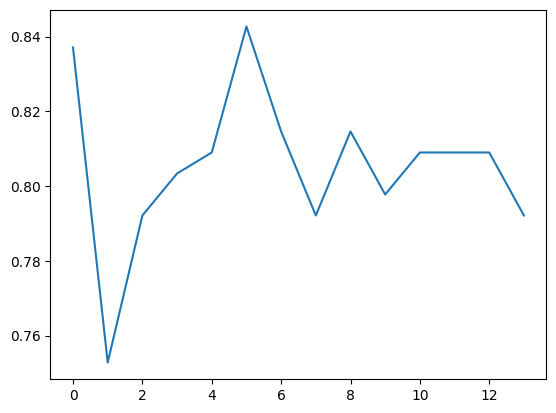

In [37]:
sb.lineplot(data=resultados)

In [38]:
modelo = DecisionTreeClassifier(max_depth=8)
modelo.fit(x_ent, y_ent)
predicciones = modelo.predict(x_pru)
exactitud = accuracy_score(y_pru, predicciones)

In [39]:
from sklearn.metrics import classification_report
print(classification_report(y_pru, predicciones))

              precision    recall  f1-score   support

           0       0.75      0.93      0.83        98
           1       0.88      0.61      0.72        80

    accuracy                           0.79       178
   macro avg       0.81      0.77      0.77       178
weighted avg       0.80      0.79      0.78       178



In [40]:
from sklearn.metrics import confusion_matrix

pd.DataFrame(confusion_matrix(y_pru, predicciones), columns=["Pred: No", "Pred: Si"], index=["Real: No", "Real: Si"])

,Pred: No,Pred: Si
Real: No,91,7
Real: Si,31,49


In [41]:
x_ent.columns

Index(['Pclass', 'Age', 'SibSp', 'Parch', 'Fare', 'male', 'Q', 'S'], dtype='object')

[Text(0.4870535714285714, 0.9444444444444444, 'male <= 0.5\n0.464\n711\n[451, 260]\nMurio'),
 Text(0.25, 0.8333333333333334, 'Pclass <= 2.5\n0.418\n245\n[73, 172]\nVivio'),
 Text(0.3685267857142857, 0.8888888888888888, 'True  '),
 Text(0.1, 0.7222222222222222, 'Age <= 3.0\n0.13\n129\n[9, 120]\nVivio'),
 Text(0.06428571428571428, 0.6111111111111112, 'Fare <= 88.775\n0.5\n2\n[1, 1]\nMurio'),
 Text(0.05, 0.5, '0.0\n1\n[0, 1]\nVivio'),
 Text(0.07857142857142857, 0.5, '0.0\n1\n[1, 0]\nMurio'),
 Text(0.1357142857142857, 0.6111111111111112, 'Fare <= 28.856\n0.118\n127\n[8, 119]\nVivio'),
 Text(0.10714285714285714, 0.5, 'Fare <= 28.231\n0.219\n56\n[7, 49]\nVivio'),
 Text(0.09285714285714286, 0.3888888888888889, 'Age <= 56.0\n0.194\n55\n[6, 49]\nVivio'),
 Text(0.05714285714285714, 0.2777777777777778, 'SibSp <= 0.5\n0.171\n53\n[5, 48]\nVivio'),
 Text(0.02857142857142857, 0.16666666666666666, 'Fare <= 13.25\n0.1\n38\n[2, 36]\nVivio'),
 Text(0.014285714285714285, 0.05555555555555555, '0.18\n20\n[2

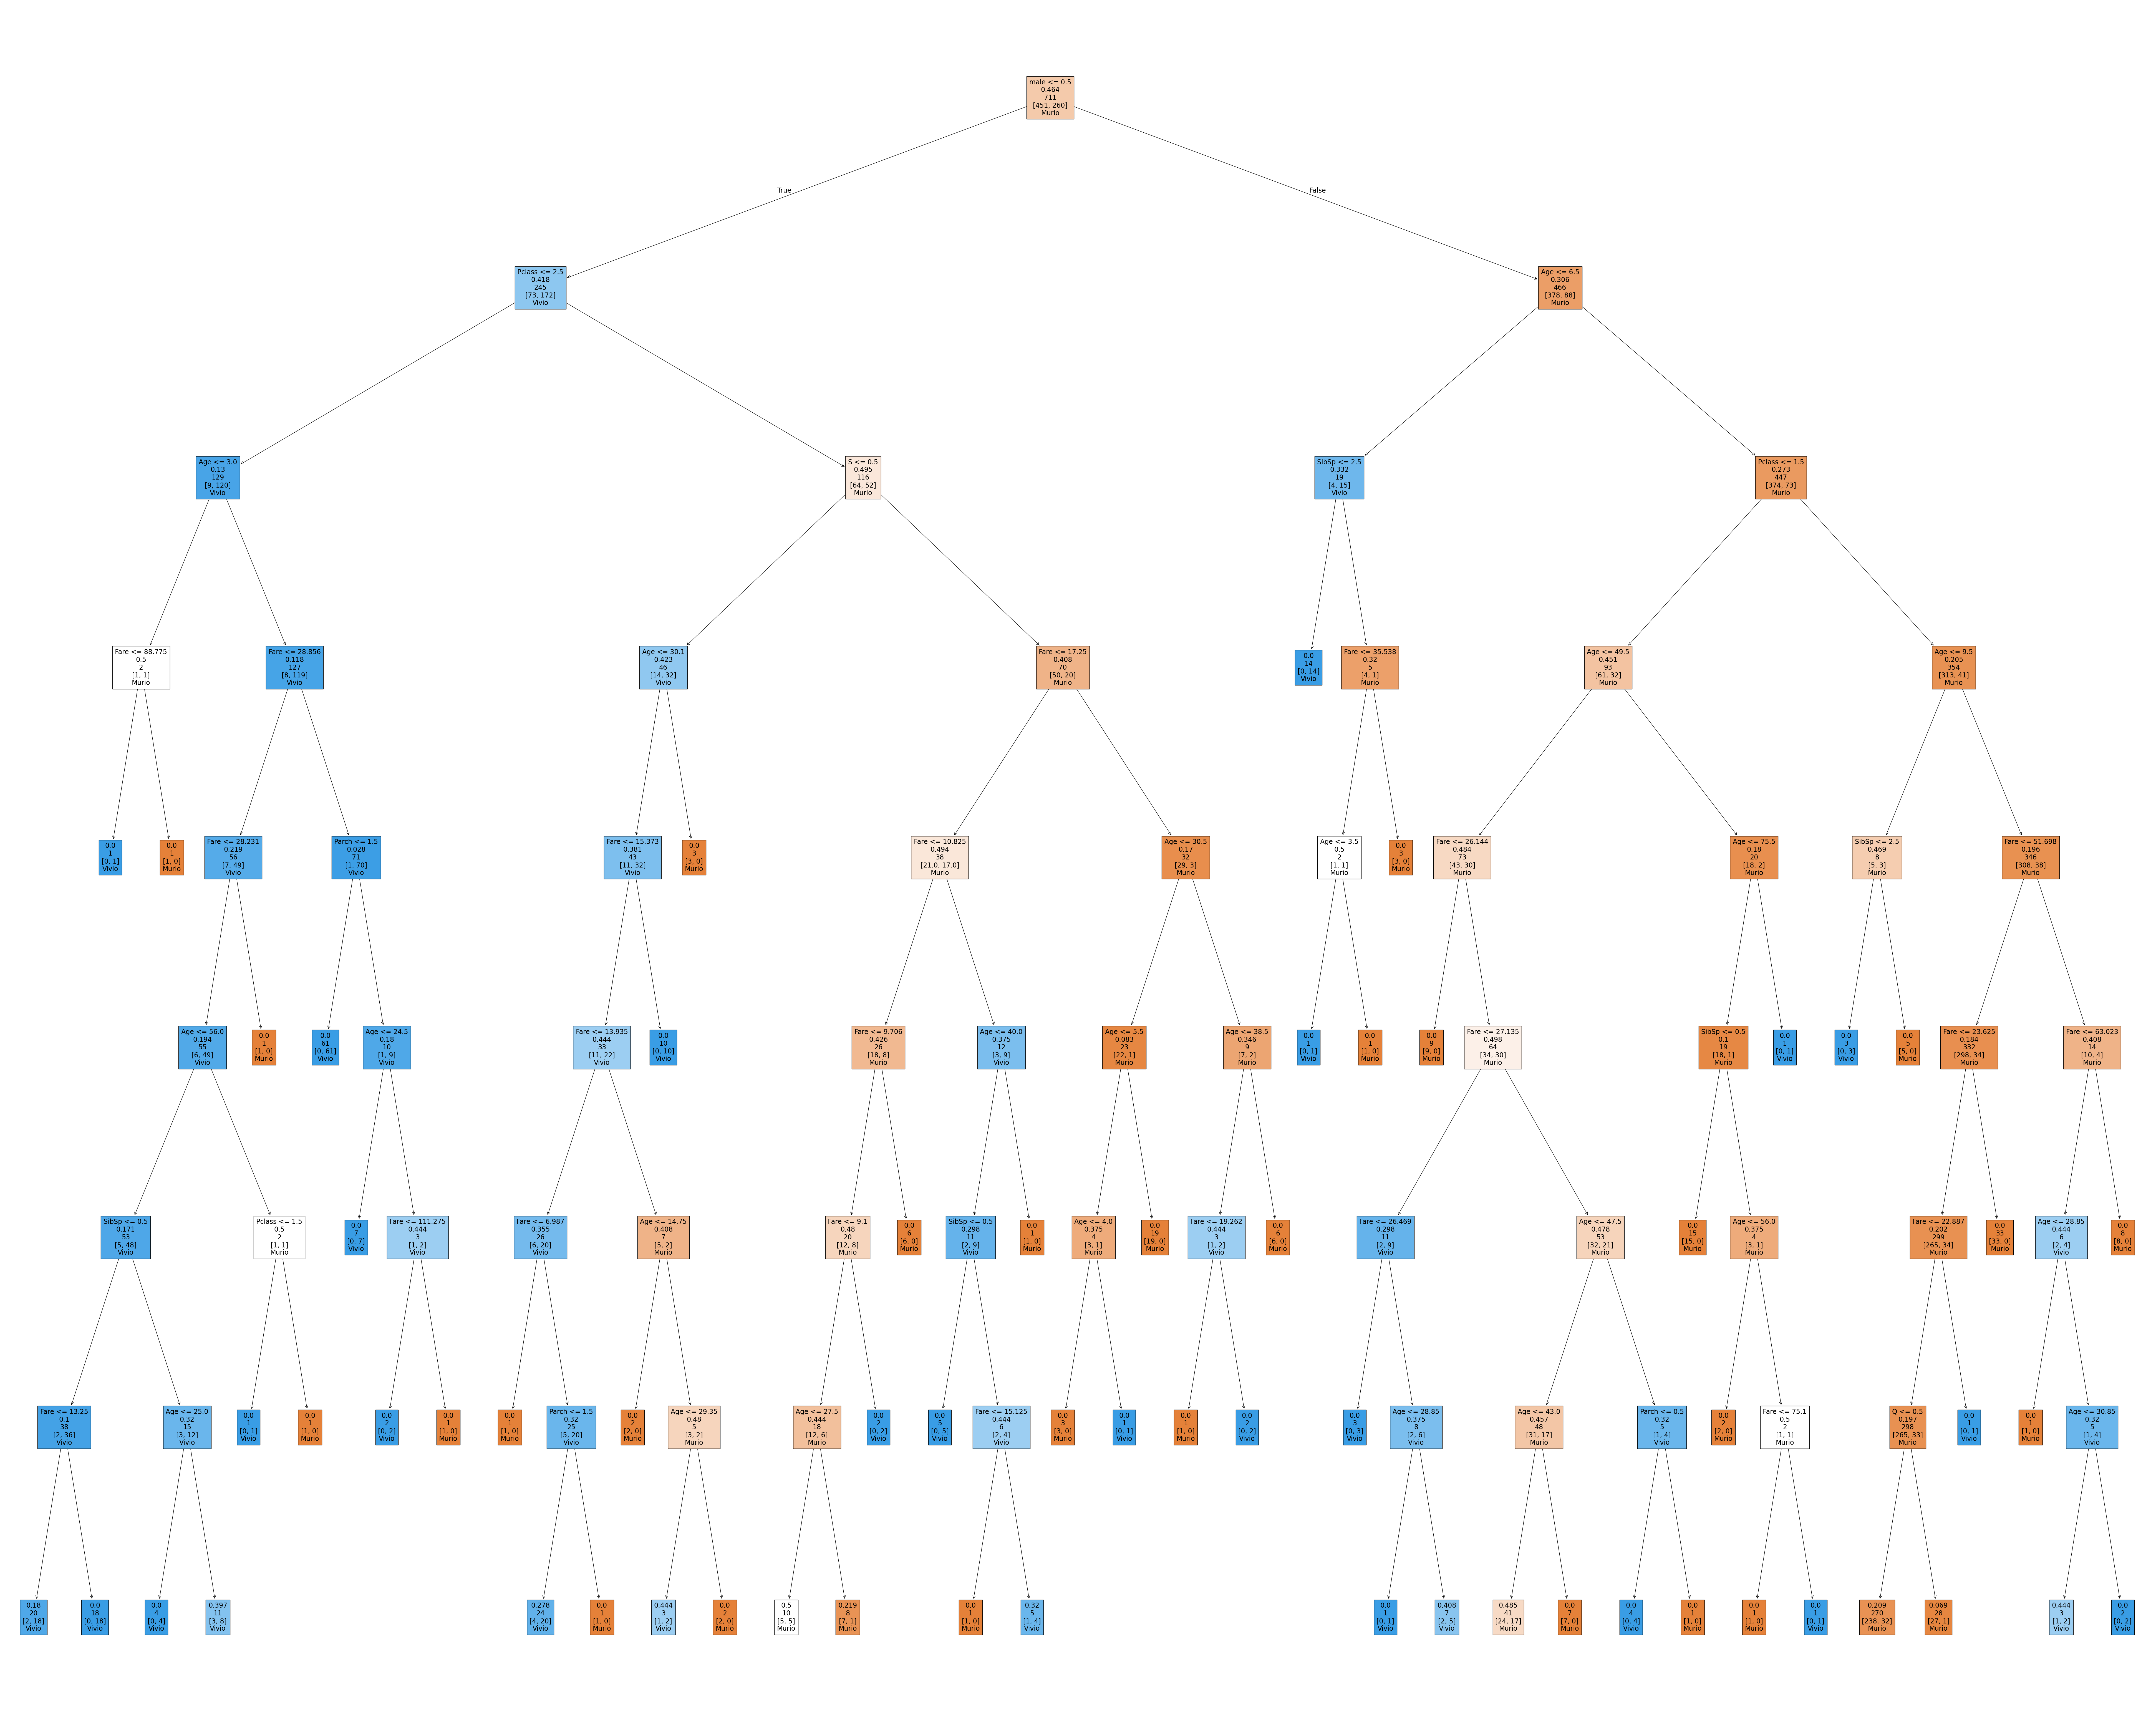

In [43]:
from sklearn.tree import plot_tree
import matplotlib.pyplot as plt

plt.figure(figsize=(100, 80))
plot_tree(
    modelo, feature_names=x_ent.columns,
    class_names=["Murio", "Vivio"],
    filled=True, label="none"
)